In [1]:
!pip install yfinance --quiet

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
oil = yf.download("CL=F", start="2015-01-01", end="2025-01-01", multi_level_index=False)
sp500 = yf.download("^GSPC", start="2015-01-01", end="2025-01-01", multi_level_index=False)

oil.head()

/tmp/ipykernel_2090/1527023878.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  oil = yf.download("CL=F", start="2015-01-01", end="2025-01-01", multi_level_index=False)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2090/1527023878.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500 = yf.download("^GSPC", start="2015-01-01", end="2025-01-01", multi_level_index=False)
[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,52.689999,55.110001,52.029999,53.759998,268708
2015-01-05,50.040001,52.730000,49.680000,52.610001,375782
2015-01-06,47.930000,50.369999,47.549999,50.000000,451642
2015-01-07,48.650002,49.310001,46.830002,48.000000,460083
2015-01-08,48.790001,49.650002,47.730000,48.779999,362081


In [3]:
df = pd.DataFrame({
 "Oil": oil["Close"],
 "SP500": sp500["Close"]
})
df = df.dropna()
df.head()

,Oil,SP500
Date,,
2015-01-02,52.689999,2058.199951
2015-01-05,50.040001,2020.579956
2015-01-06,47.930000,2002.609985
2015-01-07,48.650002,2025.900024
2015-01-08,48.790001,2062.139893


In [4]:
returns = df.pct_change().dropna()
returns.columns = ["Oil_Return", "SP500_Return"]
returns.head()

,Oil_Return,SP500_Return
Date,,
2015-01-05,-0.050294,-0.018278
2015-01-06,-0.042166,-0.008893
2015-01-07,0.015022,0.011630
2015-01-08,0.002878,0.017888
2015-01-09,-0.008813,-0.008404


In [5]:
correlation = returns["Oil_Return"].corr(returns["SP500_Return"])
print("Correlation:", correlation)

Correlation: 0.14534372362337986


In [6]:
slope, intercept, r_value, p_value, std_err = stats.linregress(
 returns["Oil_Return"], returns["SP500_Return"]
)
print("R-squared:", r_value**2)
print("p-value:", p_value)

R-squared: 0.021124797996709428
p-value: 2.4550863806985005e-13


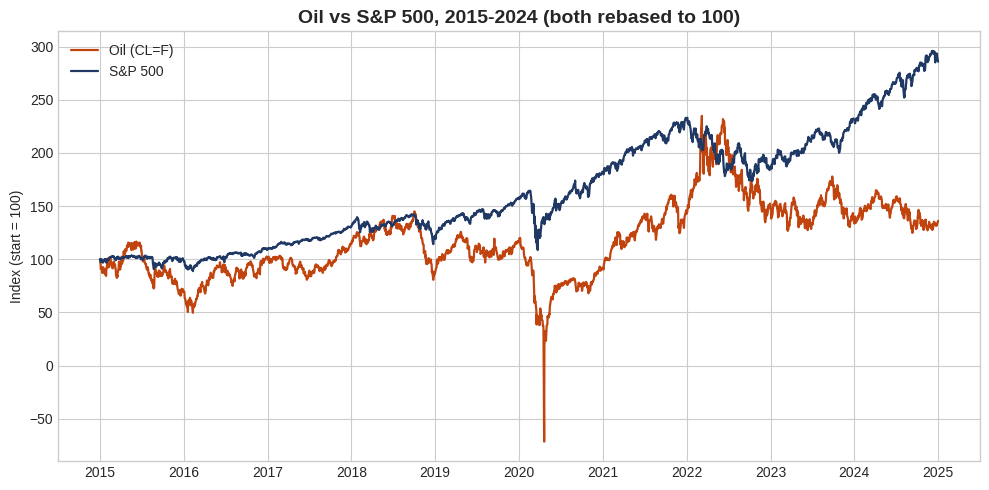

In [7]:
plt.style.use("seaborn-v0_8-whitegrid")

indexed = df / df.iloc[0] * 100 # both series start at 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(indexed.index, indexed["Oil"], label="Oil (CL=F)",
 linewidth=1.6, color="#C1440E")
ax.plot(indexed.index, indexed["SP500"], label="S&P 500",
 linewidth=1.6, color="#1F3864")
ax.set_title("Oil vs S&P 500, 2015-2024 (both rebased to 100)",
 fontsize=14, weight="bold")
ax.set_ylabel("Index (start = 100)")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig("chart1_timeseries.png", dpi=130) # saves the image
plt.show()


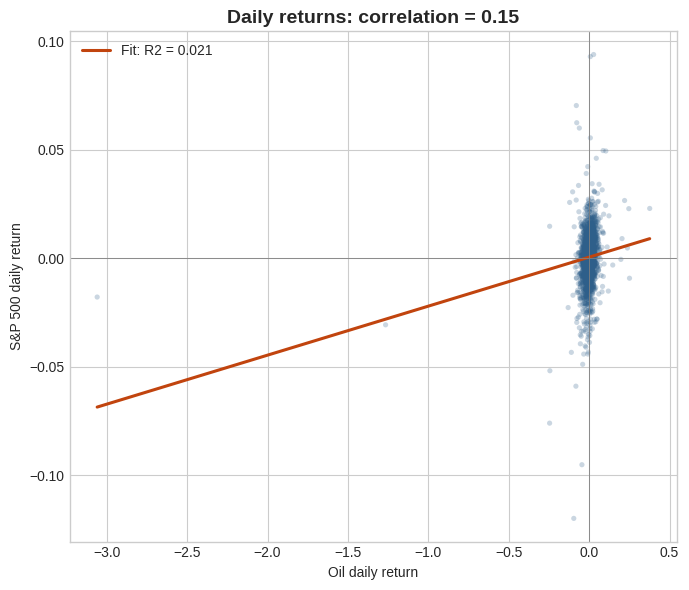

In [8]:
import numpy as np

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(returns["Oil_Return"], returns["SP500_Return"],
 alpha=0.25, s=14, color="#2E5F8A", edgecolors="none")

xs = np.linspace(returns["Oil_Return"].min(),
 returns["Oil_Return"].max(), 100)
ax.plot(xs, intercept + slope * xs, color="#C1440E", linewidth=2.2,
 label=f"Fit: R2 = {r_value**2:.3f}")

ax.set_xlabel("Oil daily return")
ax.set_ylabel("S&P 500 daily return")
ax.set_title(f"Daily returns: correlation = {correlation:.2f}",
 fontsize=14, weight="bold")
ax.axhline(0, color="grey", linewidth=0.6)
ax.axvline(0, color="grey", linewidth=0.6)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig("chart2_scatter.png", dpi=130)
plt.show()

**The Question**
This project investigates whether there is a relationship between daily changes in oil prices and the daily returns of the S&P 500 stock market index. Understanding this relationship can provide insight into how changes in energy markets may be associated with overall stock market performance.
**The Data**
The data was collected from Yahoo Finance using the yfinance Python library. Historical daily adjusted closing prices for crude oil and the S&P 500 were downloaded, combined into a single dataset, cleaned by removing missing values, and converted into daily percentage returns for analysis.
**The Method**
 The analysis used the Pearson correlation coefficient to measure the strength of the relationship between oil returns and S&P 500 returns. A simple linear regression was also performed to calculate the R-squared value and p-value, which help evaluate how well oil returns explain movements in the S&P 500 and whether the relationship is statistically significant.
**The Results**
  The analysis produced a correlation coefficient of 0.1453, indicating a weak positive relationship between oil returns and S&P 500 returns. The R-squared value was 0.0211, meaning oil returns explain approximately 2.1% of the variation in S&P 500 returns. The p-value was 2.46 × 10⁻¹³, indicating that the relationship is statistically significant, although the overall effect is weak.
**Limitations** This analysis examines correlation rather than causation, so it cannot prove that changes in oil prices cause changes in the S&P 500. Many other factors, such as interest rates, inflation, economic conditions, and global events, can influence stock market performance. Future studies could include additional variables or longer time periods to provide a more comprehensive analysis.
